In [1]:
import os

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
import keras
layers = tf.keras.layers

KeyboardInterrupt: 

In [ ]:
os.makedirs("models", exist_ok=True)

In [ ]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)


def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



In [ ]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

n_classes = len(cifar10_labels)


images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


In [ ]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Hint: normalize the data
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0
# Hint: use 20% of the test data for validation
x_valid_norm = x_test_norm[8000:]
x_test_norm = x_test_norm[:8000]


In [ ]:
def dense_block(x, n=8):
    """ 
    Creates of n densely connected pairs of convolutions
    """
    xlist = [x]

    for i in range(n):
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(8, (3,3), padding='same')(x)
        # x = layers.Conv2D(8, (3,3), padding='same', activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        xlist.append(x)
        x = layers.concatenate(xlist[:], axis=-1) # axis -1 for feature space
    return x

In [ ]:
# Define Model -> Dense Conv Model

        
x0 = layers.Input(shape=(32,32,3), name='input')

x = dense_block(x0)

x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = layers.AveragePooling2D((2,2), strides=(2,2))(x)

x = dense_block(x)

# maybe add more here but first try the example from the lecture

x = layers.GlobalAveragePooling2D(name='final_globalpooling')(x)

x = layers.Dropout(0.3, name='final_dropout')(x)
x = layers.Dense(n_classes, activation='softmax')(x)

model = keras.models.Model(inputs=[x0], outputs=[x], name='DenseNet')

In [ ]:
print(model.summary())

Model: "DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 32, 32, 8) │        224 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_32      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 11)               │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32, 8) │        800 │ concatenate_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_33      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 19)               │            │ conv2d_36[0][0],  │
│                     │                   │            │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 32, 32, 8) │      1,376 │ concatenate_33[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_34      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 27)               │            │ conv2d_36[0][0],  │
│                     │                   │            │ conv2d_37[0][0],  │
│                     │                   │            │ conv2d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32, 8) │      1,952 │ concatenate_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_35      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 35)               │            │ conv2d_36[0][0],  │
│                     │                   │            │ conv2d_37[0][0],  │
│                     │                   │            │ conv2d_38[0][0],  │
│                     │                   │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 32, 32, 8) │      2,528 │ concatenate_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 43)               │            │ conv2d_36[0][0],  │
│                     │                   │            │ conv2d_37[0][0],  │
│                     │                   │            │ conv2d_38[0][0],  │
│                     │                   │            │ conv2d_39[0][0],  │
│                     │                   │            │ conv2d_40[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 32, 32, 8) │      3,104 │ concatenate_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_37      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 51)               │            │ conv2d_36[0][0],  │
│                     │                   │            │ conv2d_37[0][0],  │
│                     │                   │            │ conv2d_38[0][0],  │
│                     │                   │            │ conv2d_39[0][0],  │
│                     │                   │            │ conv2d_40[0][0],  │
│                     │                   │            │ conv2d_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32, 8) │      3,680 │ concatenate_37[0… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 76,618 (299.29 KB)

 Trainable params: 76,618 (299.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# training
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()],
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=32,
    epochs=40,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[keras.callbacks.CSVLogger("history_{}.csv".format(model.name))]
)

model.save('models/{}.keras'.format(model.name))

Epoch 1/40


2026-06-10 22:11:16.360220: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 64ms/step - categorical_accuracy: 0.3323 - loss: 1.7743 - val_categorical_accuracy: 0.4535 - val_loss: 1.5010
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - categorical_accuracy: 0.4804 - loss: 1.4139 - val_categorical_accuracy: 0.5125 - val_loss: 1.3284
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - categorical_accuracy: 0.5616 - loss: 1.2074 - val_categorical_accuracy: 0.5975 - val_loss: 1.1373
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 62ms/step - categorical_accuracy: 0.6100 - loss: 1.0828 - val_categorical_accuracy: 0.6185 - val_loss: 1.0523
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - categorical_accuracy: 0.6441 - loss: 0.9959 - val_categorical_accuracy: 0.6385 - val_loss: 1.0075
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 62ms/step - categorical_accuracy: 0.6699 - loss: 0.9301 - val_categorical_accuracy: 0.6450 - val_loss: 0.9546
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 59ms/step - categorical_ac

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


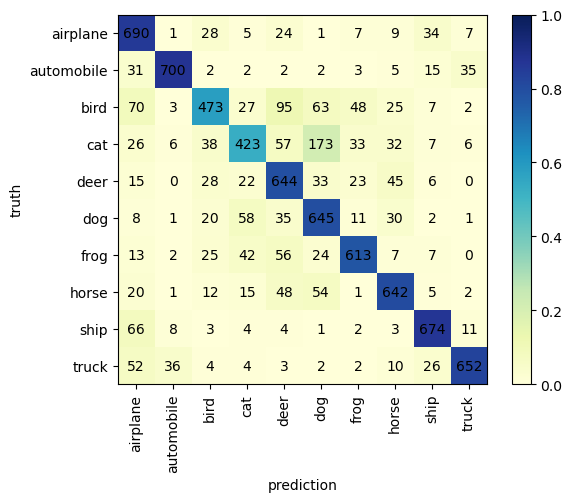

In [ ]:
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("history_DenseNet.csv")

/var/folders/92/vd53kdfd5v7c7_j3f5mmq2r00000gn/T/ipykernel_13936/3821826948.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


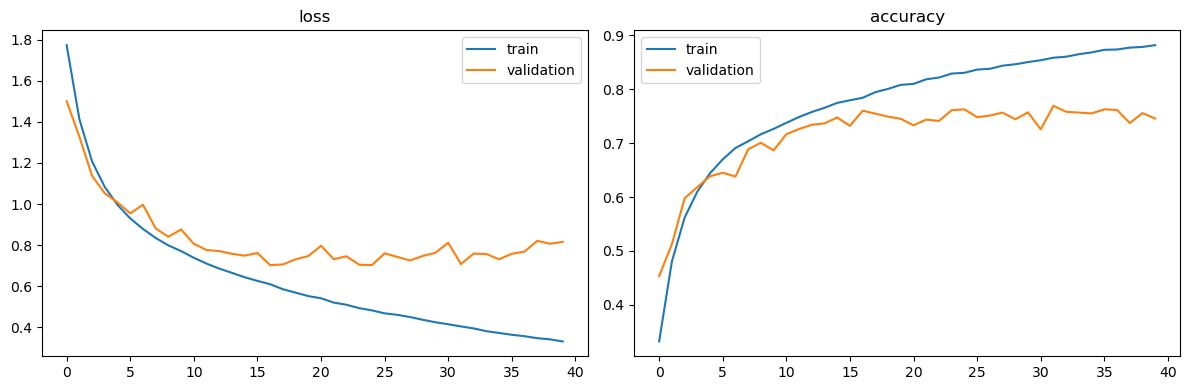

In [ ]:
# plot training history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df["loss"], label="train")
ax[0].plot(df["val_loss"], label="validation")
ax[0].set_title("loss")
ax[0].legend()

ax[1].plot(df["categorical_accuracy"], label="train")
ax[1].plot(df["val_categorical_accuracy"], label="validation")
ax[1].set_title("accuracy")
ax[1].legend()

fig.tight_layout()
fig.show()
